# Retail Sales Exploratory Data Analysis

This notebook explores retail transaction patterns across time, customer demographics, and product categories, and turns observed patterns into cautious, testable business recommendations.

**Dataset:** the 1,000-row `retail_sales_dataset.csv` published on Kaggle as [Retail Sales Dataset](https://www.kaggle.com/datasets/mohammadtalib/retail-sales-dataset). A public file copy is downloaded from [romulolacerda/analise-vendas on GitHub](https://github.com/romulolacerda/analise-vendas/blob/0e792eb7f9c0d807bc1b247305527ff11b9f73e0/retail_sales_dataset.csv); that repository identifies the file as `retail_sales_dataset.csv`.

**Dataset limitation:** the source has transaction date, customer demographics, category, quantity, price per unit, and total amount, but it has no product/SKU identifier, item description, transaction time, branch/store, cost, or profit. Thus the product ranking below can only rank the three available **categories** (not ten individual products), and revenue is not the same as profit. Its observed date span is 2023-01-01 through 2024-01-01 (about one year), so it cannot establish recurring long-run seasonality or year-over-year growth. Treat patterns as descriptive and recommendations as hypotheses to test.

## 1. Imports and source data

The lookup works from this `DATA ANALYTICS` folder or from the parent project directory.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110

data_candidates = [Path.cwd() / "data", Path.cwd().parent / "data"]
data_dir = next((path for path in data_candidates if path.is_dir()), None)
if data_dir is None:
    raise FileNotFoundError("Could not find the DATA ANALYTICS/data folder.")
data_path = data_dir / "retail_sales_dataset.csv"
if not data_path.is_file():
    raise FileNotFoundError(f"Retail dataset not found: {data_path}")
raw = pd.read_csv(data_path)
print(f"Loaded {data_path.resolve()}")
print(f"Shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")

Loaded C:\Users\Sreeyakeshrajan_T\OneDrive\Desktop\OIBSIP\DATA ANALYTICS\data\retail_sales_dataset.csv
Shape: 1,000 rows x 9 columns


## 2. Initial inspection and cleaning

Inspect field names, types, nulls, and duplicates. Parse dates and validate numeric fields before analysis. `Total Amount` is treated as the source's sales/revenue measure; where quantity and unit price are both present, compare their product to identify possible inconsistencies rather than silently overwriting the source.

In [2]:
print("Source columns:", raw.columns.tolist())
display(raw.head())
print("\nSource dtypes:")
display(raw.dtypes.rename("dtype").to_frame())
print("\nMissing values:")
display(raw.isna().sum().rename("missing_count").to_frame())
print(f"\nExact duplicate rows: {raw.duplicated().sum():,}")

df = raw.copy()
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)
text_columns = ["gender", "product_category"]
for column in text_columns:
    if column in df.columns:
        df[column] = df[column].astype("string").str.strip().str.title()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
numeric_columns = ["transaction_id", "age", "quantity", "price_per_unit", "total_amount"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

duplicates_removed = int(df.duplicated().sum())
required = ["transaction_id", "date", "customer_id", "gender", "age", "product_category", "quantity", "price_per_unit", "total_amount"]
missing_required_rows = int(df[required].isna().any(axis=1).sum())
df = df.drop_duplicates().dropna(subset=required).copy()
valid_rows = (
    df["age"].between(0, 120)
    & df["quantity"].gt(0)
    & df["price_per_unit"].ge(0)
    & df["total_amount"].ge(0)
)
invalid_value_rows = int((~valid_rows).sum())
df = df.loc[valid_rows].copy()
df = df.sort_values("date").reset_index(drop=True)

df["year_month"] = df["date"].dt.to_period("M")
df["quarter"] = df["date"].dt.to_period("Q")
df["age_group"] = pd.cut(
    df["age"], bins=[0, 18, 25, 35, 45, 55, 65, 120],
    labels=["Under 18", "18–24", "25–34", "35–44", "45–54", "55–64", "65+"],
    right=False,
)
df["weekday"] = df["date"].dt.day_name()
df["weekday_order"] = df["date"].dt.dayofweek
df["calculated_amount"] = df["quantity"] * df["price_per_unit"]
df["amount_difference"] = df["total_amount"] - df["calculated_amount"]

print(f"\nDuplicates removed: {duplicates_removed}")
print(f"Rows with missing/unparseable required values removed: {missing_required_rows}")
print(f"Rows with invalid age/quantity/price/amount removed: {invalid_value_rows}")
print(f"Clean rows retained: {len(df):,}")
print(f"Date span: {df['date'].min():%Y-%m-%d} to {df['date'].max():%Y-%m-%d}")
print(f"Unique customers: {df['customer_id'].nunique():,} | Categories: {df['product_category'].nunique()}")
print(f"Rows where source amount differs from quantity × unit price: {(df['amount_difference'].abs() > 0.01).sum():,}")
display(df[required].isna().sum().rename("missing_after_cleaning").to_frame())

Source columns: ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100



Source dtypes:


,dtype
Transaction ID,int64
Date,str
Customer ID,str
Gender,str
Age,int64
Product Category,str
Quantity,int64
Price per Unit,int64
Total Amount,int64



Missing values:


,missing_count
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0



Exact duplicate rows: 0

Duplicates removed: 0
Rows with missing/unparseable required values removed: 0
Rows with invalid age/quantity/price/amount removed: 0
Clean rows retained: 1,000
Date span: 2023-01-01 to 2024-01-01
Unique customers: 1,000 | Categories: 3
Rows where source amount differs from quantity × unit price: 0


,missing_after_cleaning
transaction_id,0
date,0
customer_id,0
gender,0
age,0
product_category,0
quantity,0
price_per_unit,0
total_amount,0


## 3. Descriptive statistics for numerical measures

Report mean, median, mode, and sample standard deviation for every numerical measure in the source. `Transaction ID` is an identifier, not a quantitative measure, so it is excluded from statistical interpretation. Modes can be tied; all tied values are retained in the table.

In [3]:
numerical_columns = ["age", "quantity", "price_per_unit", "total_amount"]
statistics = []
for column in numerical_columns:
    series = df[column].dropna()
    modes = series.mode()
    statistics.append({
        "column": column,
        "mean": series.mean(),
        "median": series.median(),
        "mode(s)": ", ".join(str(value) for value in modes.tolist()[:10]),
        "std_dev": series.std(ddof=1),
    })
descriptive_stats = pd.DataFrame(statistics).set_index("column")
display(descriptive_stats.round(2))

,mean,median,mode(s),std_dev
column,,,,
transaction_id,500.50,500.5,"1, 2, 3, 4, 5, 6, 7, 8, 9, 10",288.82
age,41.39,42.0,"43, 64",13.68
quantity,2.51,3.0,4,1.13
price_per_unit,179.89,50.0,50,189.68
total_amount,456.00,135.0,50,560.00
weekday_order,2.96,3.0,1,2.02
calculated_amount,456.00,135.0,50,560.00
amount_difference,0.00,0.0,0,0.00


## 4. Monthly sales trend

Aggregate transaction sales by calendar month. Months with no records are shown as gaps in the series; do not interpret a missing month as zero sales.

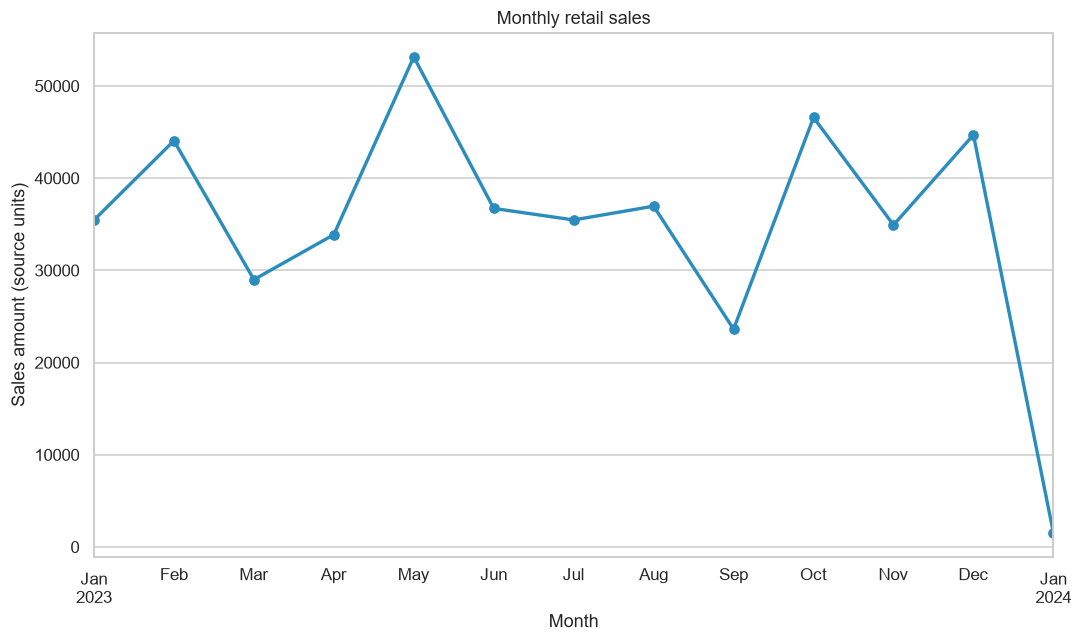

,sales_amount
year_month,
2023-01-01,35450
2023-02-01,44060
2023-03-01,28990
2023-04-01,33870
2023-05-01,53150
2023-06-01,36715
2023-07-01,35465
2023-08-01,36960
2023-09-01,23620


Observed monthly peak: May 2023 (53,150.00); lowest observed month: January 2024 (1,530.00).


In [4]:
monthly_sales = df.groupby("year_month")["total_amount"].sum().sort_index()
monthly_sales.index = monthly_sales.index.to_timestamp()
ax = monthly_sales.plot(marker="o", linewidth=2.2, color="#2b8cbe")
ax.set(title="Monthly retail sales", xlabel="Month", ylabel="Sales amount (source units)")
plt.tight_layout()
plt.show()
display(monthly_sales.rename("sales_amount").to_frame().round(2))
peak_month = monthly_sales.idxmax()
low_month = monthly_sales.idxmin()
print(f"Observed monthly peak: {peak_month:%B %Y} ({monthly_sales.max():,.2f}); lowest observed month: {low_month:%B %Y} ({monthly_sales.min():,.2f}).")

**Observation:** compare the monthly totals and note the highest and lowest observed months printed above. The observed span is 2023-01-01 through 2024-01-01, with only a single January 2024 observation; it is too short to confirm recurring seasonal demand.

## 5. Quarterly sales trend

Quarterly totals smooth some month-to-month variation while preserving the observed calendar-year structure.

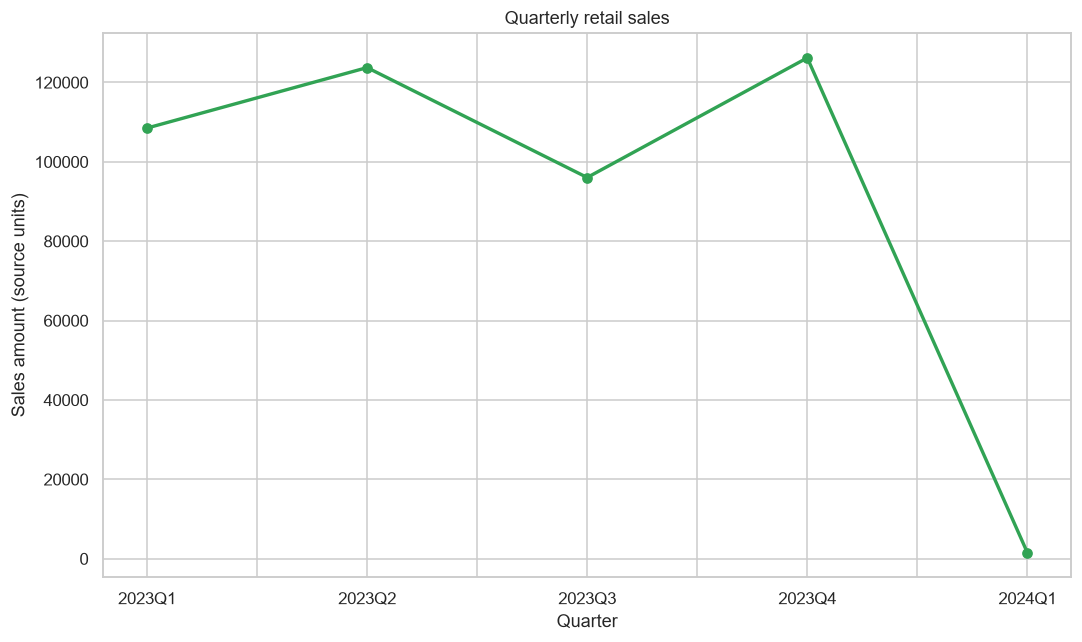

,sales_amount
quarter,
2023Q1,108500
2023Q2,123735
2023Q3,96045
2023Q4,126190
2024Q1,1530


Highest-sales observed quarter: 2023Q4 (126,190.00).


In [5]:
quarterly_sales = df.groupby("quarter")["total_amount"].sum().sort_index()
quarter_labels = quarterly_sales.index.astype(str)
ax = quarterly_sales.set_axis(quarter_labels).plot(marker="o", linewidth=2.2, color="#31a354")
ax.set(title="Quarterly retail sales", xlabel="Quarter", ylabel="Sales amount (source units)")
plt.tight_layout()
plt.show()
display(quarterly_sales.rename_axis("quarter").rename("sales_amount").to_frame().round(2))
best_quarter = quarterly_sales.idxmax()
print(f"Highest-sales observed quarter: {best_quarter} ({quarterly_sales.max():,.2f}).")

**Observation:** compare the quarterly totals. A single year's four quarters are not enough to separate seasonality from one-off changes or sampling differences.

## 6. Customer age-group distribution

Age bands are defined explicitly in the cleaning step. The count chart describes transactions, not necessarily distinct customers; the source may contain repeated customer IDs.

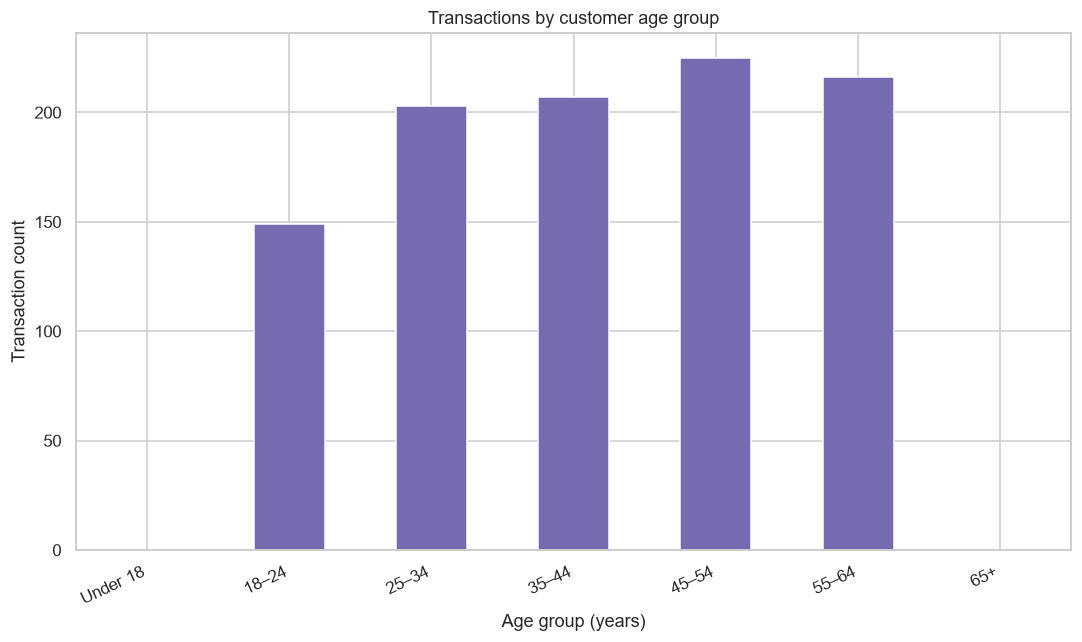

,transactions
age_group,
Under 18,0
18–24,149
25–34,203
35–44,207
45–54,225
55–64,216
65+,0


Most represented age band by transaction count: 45–54 (225 transactions).


In [6]:
age_group_counts = df["age_group"].value_counts(sort=False)
ax = age_group_counts.plot(kind="bar", color="#756bb1")
ax.set(title="Transactions by customer age group", xlabel="Age group (years)", ylabel="Transaction count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()
display(age_group_counts.rename("transactions").to_frame())
top_age_group = age_group_counts.idxmax()
print(f"Most represented age band by transaction count: {top_age_group} ({age_group_counts.max()} transactions).")

**Observation:** identify the most represented age bands and compare their transaction counts. Counts do not establish that a group has higher spending per customer; customer-level frequency and the number of customers in each group should also be considered.

## 7. Gender breakdown

Compare both transaction counts and sales totals by the source's gender labels. These recorded categories are used as provided after trimming and capitalization.

,transactions,sales_amount,average_transaction,unique_customers
gender,,,,
Female,510,232840,456.55,510
Male,490,223160,455.43,490


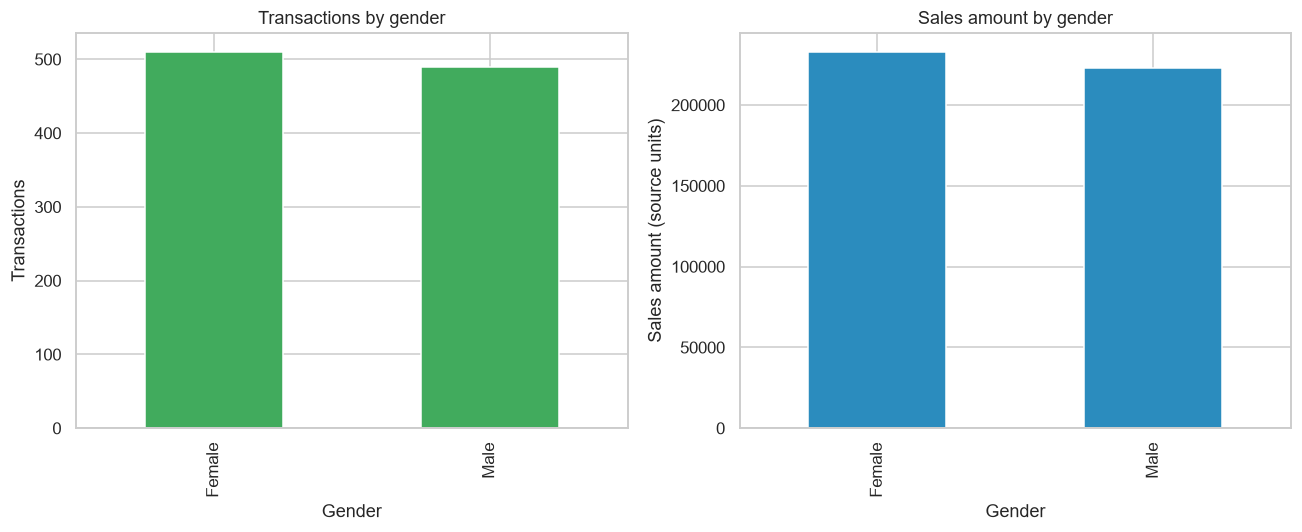

In [7]:
gender_summary = df.groupby("gender").agg(
    transactions=("transaction_id", "count"),
    sales_amount=("total_amount", "sum"),
    average_transaction=("total_amount", "mean"),
    unique_customers=("customer_id", "nunique"),
)
display(gender_summary.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gender_summary["transactions"].plot(kind="bar", ax=axes[0], color="#41ab5d")
axes[0].set(title="Transactions by gender", xlabel="Gender", ylabel="Transactions")
gender_summary["sales_amount"].plot(kind="bar", ax=axes[1], color="#2b8cbe")
axes[1].set(title="Sales amount by gender", xlabel="Gender", ylabel="Sales amount (source units)")
plt.tight_layout()
plt.show()

**Observation:** review transaction count, unique customers, sales total, and average transaction together. A higher total may reflect more transactions or customers rather than higher spending per customer.

## 8. Best-selling available items and revenue by category

The file contains `Product Category` but no product/SKU field. Therefore, an individual-product top-10 chart is not possible. We rank every available category by units and show category revenue, explicitly avoiding the invention of product identifiers.

,units_sold,transaction_count,sales_amount,average_transaction
product_category,,,,
Clothing,894,351,155580,443.25
Electronics,849,342,156905,458.79
Beauty,771,307,143515,467.48


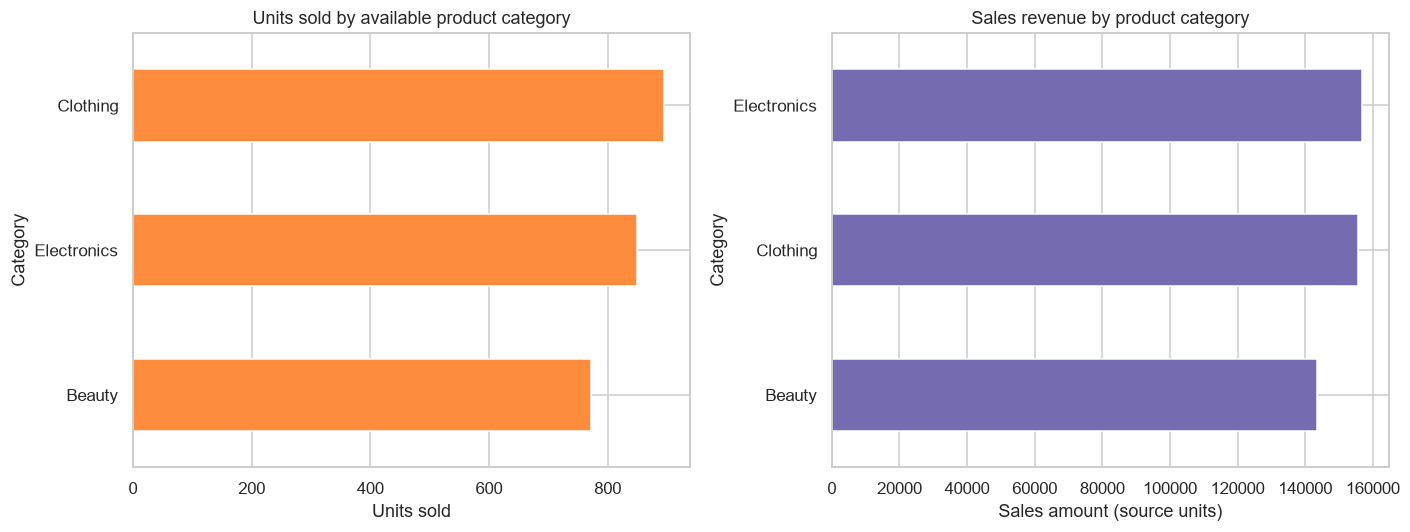

Highest-revenue category: Electronics (156,905.00).


In [8]:
category_summary = df.groupby("product_category").agg(
    units_sold=("quantity", "sum"),
    transaction_count=("transaction_id", "count"),
    sales_amount=("total_amount", "sum"),
    average_transaction=("total_amount", "mean"),
).sort_values("units_sold", ascending=False)
display(category_summary.round(2))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
category_summary["units_sold"].sort_values().plot(kind="barh", ax=axes[0], color="#fd8d3c")
axes[0].set(title="Units sold by available product category", xlabel="Units sold", ylabel="Category")
category_summary["sales_amount"].sort_values().plot(kind="barh", ax=axes[1], color="#756bb1")
axes[1].set(title="Sales revenue by product category", xlabel="Sales amount (source units)", ylabel="Category")
plt.tight_layout()
plt.show()
top_category = category_summary["sales_amount"].idxmax()
print(f"Highest-revenue category: {top_category} ({category_summary.loc[top_category, 'sales_amount']:,.2f}).")

**Observation:** compare category units with category revenue; a category can lead in units without leading in sales value. Add item-level product codes and cost data to a future extract to support SKU-level assortment and profitability decisions.

## 9. Correlation among numerical variables

Inspect correlations between age, quantity, unit price, and total amount. `Transaction ID` is an identifier, so it is excluded. Total Amount is structurally related to quantity and price, and correlation should not be interpreted causally.

,age,quantity,price_per_unit,total_amount
age,1.000,-0.024,-0.038,-0.061
quantity,-0.024,1.000,0.018,0.374
price_per_unit,-0.038,0.018,1.000,0.852
total_amount,-0.061,0.374,0.852,1.000


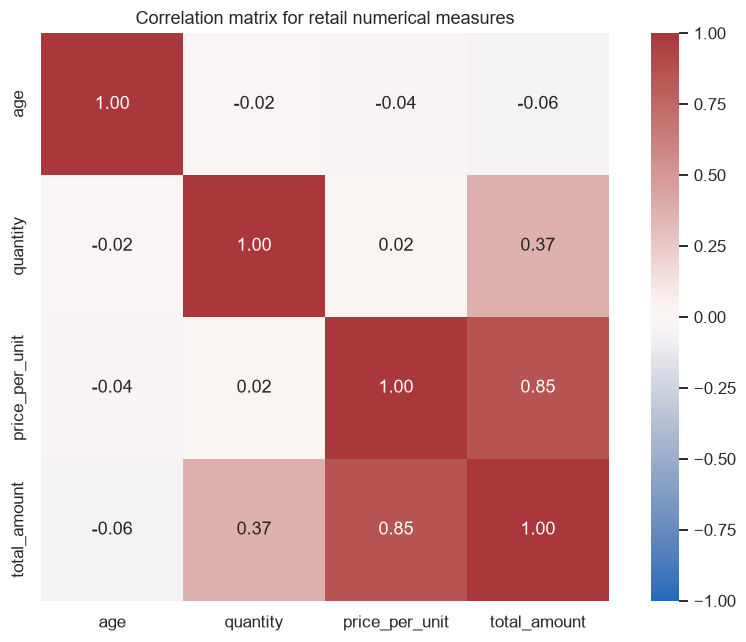

In [9]:
corr_columns = ["age", "quantity", "price_per_unit", "total_amount"]
correlation = df[corr_columns].corr()
display(correlation.round(3))
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlation matrix for retail numerical measures")
plt.tight_layout()
plt.show()

**Observation:** note which numerical variables move together in this sample. Since sales amount is generally computed from quantity and price, an association with either is expected and should not be presented as a discovered causal driver.

## 10. Additional view: category mix by age group

This heatmap normalizes each age-group row to show its share of transactions across categories. It can reveal differences in category mix that overall totals may hide. Small group counts make shares unstable, so read it alongside the counts.

product_category,Beauty,Clothing,Electronics
age_group,,,
18–24,53,45,51
25–34,68,73,62
35–44,51,79,77
45–54,73,74,78
55–64,62,80,74


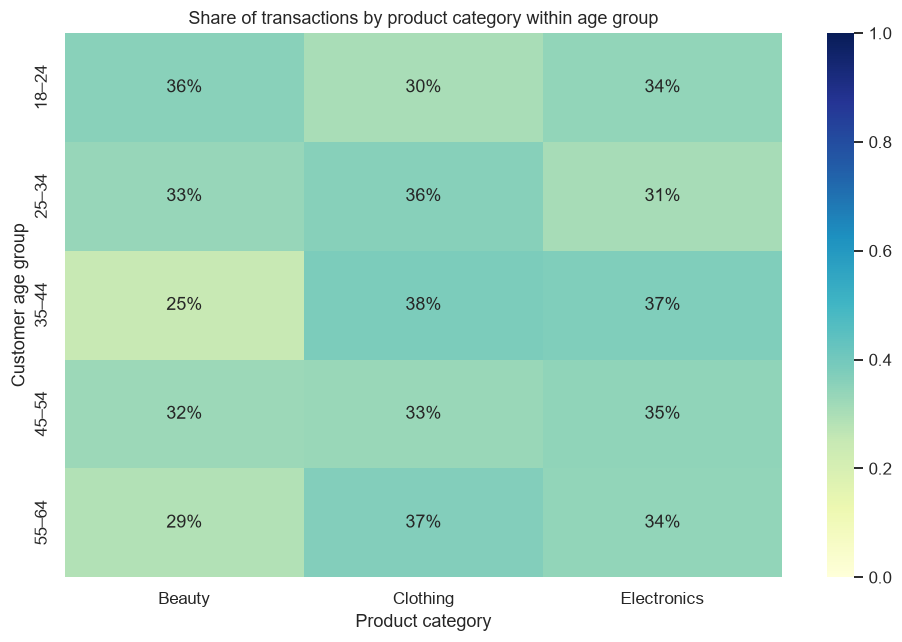

product_category,Beauty,Clothing,Electronics
age_group,,,
Under 18,0,0,0
18–24,28905,22160,23585
25–34,28540,41640,26910
35–44,29450,30925,36460
45–54,35950,29545,31740
55–64,20670,31310,38210
65+,0,0,0


In [10]:
age_category_counts = pd.crosstab(df["age_group"], df["product_category"])
age_category_share = age_category_counts.div(age_category_counts.sum(axis=1), axis=0)
display(age_category_counts)
plt.figure(figsize=(9, 6))
sns.heatmap(age_category_share, annot=True, fmt=".0%", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Share of transactions by product category within age group")
plt.xlabel("Product category")
plt.ylabel("Customer age group")
plt.tight_layout()
plt.show()
age_category_revenue = df.pivot_table(
    index="age_group", columns="product_category", values="total_amount", aggfunc="sum", observed=False
).fillna(0)
display(age_category_revenue.round(2))

**Observation:** compare row percentages and sample counts. A different category mix can motivate a small, measured merchandising test, but it does not establish preference for the population because the dataset's sampling design is undocumented.

## 11. Actionable recommendations

The recommendations below are populated from the computed summaries. They are framed as operational tests, not causal conclusions. Because this file lacks profit, store, campaign, and multi-year data, validate any action with a controlled pilot and margin/stockout measures.

In [11]:
top_sales_month = monthly_sales.idxmax()
top_sales_month_value = monthly_sales.max()
top_sales_quarter = quarterly_sales.idxmax()
top_category_name = category_summary["sales_amount"].idxmax()
top_category_units = category_summary["units_sold"].idxmax()
top_gender = gender_summary["sales_amount"].idxmax()
top_gender_share = gender_summary.loc[top_gender, "sales_amount"] / df["total_amount"].sum()
top_age_revenue_group = df.groupby("age_group", observed=False)["total_amount"].sum().idxmax()
top_age_revenue = df.groupby("age_group", observed=False)["total_amount"].sum().max()

print("1. Use the peak observed month as a planning hypothesis:")
print(f"   {top_sales_month:%B %Y} had the highest monthly sales ({top_sales_month_value:,.2f}). Review replenishment and promotional readiness before a comparable period, then compare against multiple years before making it a recurring seasonal plan.")
print("\n2. Pilot category-specific inventory and merchandising:")
print(f"   {top_category_name} led category revenue, while {top_category_units} led units sold. Track both margin and stockouts in a limited assortment/display test before shifting inventory.")
print("\n3. Test targeted customer communication without assuming demographics cause spend:")
print(f"   {top_age_revenue_group} produced the largest observed age-band revenue ({top_age_revenue:,.2f}); {top_gender} transactions contributed {top_gender_share:.1%} of recorded sales. Test relevant, inclusive offers with a holdout group and compare incremental margin, not just revenue.")
print("\n4. Improve data collection:")
print("   Capture product/SKU, transaction time, store, cost/margin, and a longer date history. These fields enable a real top-10 product ranking, profit analysis, and stronger seasonality checks.")

1. Use the peak observed month as a planning hypothesis:
   May 2023 had the highest monthly sales (53,150.00). Review replenishment and promotional readiness before a comparable period, then compare against multiple years before making it a recurring seasonal plan.

2. Pilot category-specific inventory and merchandising:
   Electronics led category revenue, while Clothing led units sold. Track both margin and stockouts in a limited assortment/display test before shifting inventory.

3. Test targeted customer communication without assuming demographics cause spend:
   45–54 produced the largest observed age-band revenue (97,235.00); Female transactions contributed 51.1% of recorded sales. Test relevant, inclusive offers with a holdout group and compare incremental margin, not just revenue.

4. Improve data collection:
   Capture product/SKU, transaction time, store, cost/margin, and a longer date history. These fields enable a real top-10 product ranking, profit analysis, and stronger 

## 12. Conclusion

The notebook identifies observed monthly and quarterly sales patterns, customer age and gender distributions, category sales/units, numerical associations, and differences in category mix across age bands. Recommendations focus on planning around the observed peak, testing category merchandising, measuring customer outreach with a control group, and improving source data. These are descriptive results from 1,000 transactions in one year, not forecasts or causal estimates. In particular, do not infer profit from sales amount or item-level winners from category-only records.